# Part 2 — Geoeconomic Risk Dictionary Search
#
# Applies four dictionary-based queries (Trade, Sanctions, Embargo, Geopolitical)
# to identify which transcripts discuss geoeconomic risks. Each query requires a
# combination of a topic keyword AND a risk/uncertainty keyword, following the
# dictionary design used in the underlying Master Thesis.
#
# Matching logic: document-level co-occurrence (both terms appear anywhere in the
# transcript), consistent with the NL Analytics platform used in the thesis.
#
# Input:  data/corpus_documents.csv  (from 00_prepare_corpus.R)
# Output: data/geoeconomic_matches.csv — one row per transcript with match flags

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


## 1. Pattern builder

A single helper converts the user-facing keyword syntax into compiled regexes:
- `tariff*` → prefix match `\btariff\w*`
- `import dut*` → phrase + prefix `\bimport\s+dut\w*`
- `free trade` → exact phrase `\bfree\s+trade\b`
- Special terms (`(anti-)dumping`, `build-up*`, `broke out`, `arms`) handled explicitly.

In [2]:
def make_pattern(*terms):
    """
    Build a compiled OR-regex from a list of search terms.
    Trailing * = prefix wildcard.  Spaces within a term = phrase match.
    Special terms may be passed as raw regex strings prefixed with 'RE:'.
    """
    pats = []
    for term in terms:
        term = term.strip()
        if term.startswith('RE:'):
            pats.append(term[3:])
            continue
        wildcard = term.endswith('*')
        stem = term[:-1] if wildcard else term
        words = stem.split()
        joined = r'\s+'.join(re.escape(w) for w in words)
        if wildcard:
            pats.append(r'\b' + joined + r'\w*')
        else:
            pats.append(r'\b' + joined + r'\b')
    combined = '|'.join(pats)
    return re.compile(combined, re.IGNORECASE)


def hit(text, pat):
    """Return True if compiled pattern matches anywhere in text."""
    return bool(pat.search(text)) if isinstance(text, str) else False


def hit_and(text, pat_a, pat_b):
    """
    Return True only when BOTH patterns match in the SAME sentence.

    This enforces sentence-level co-occurrence rather than a looser
    document-level AND, reducing false positives from transcripts that
    merely mention e.g. 'tariff' and 'risk' in completely unrelated
    passages. A sentence is delimited by a period, exclamation mark, or
    question mark followed by whitespace.
    """
    if not isinstance(text, str):
        return False
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return any(pat_a.search(s) and pat_b.search(s) for s in sentences)


# Quick unit tests
assert hit('We face significant tariff risks on imports', make_pattern('tariff*'))
assert hit('The import duty on steel has increased', make_pattern('import dut*'))
assert hit('free trade agreements are under pressure', make_pattern('free trade'))
assert hit('anti-dumping measures were imposed',
           make_pattern('RE:' + r'\b(?:anti-)?dumping\b'))

# Sentence-level AND: both terms in same sentence → True
assert hit_and(
    'We remain concerned about potential tariff risks under the new trade policy.',
    make_pattern('tariff*'), make_pattern('risk*')
)
# Sentence-level AND: terms in different sentences → False
assert not hit_and(
    'Tariff measures were enacted this quarter. Our overall uncertainty remains low.',
    make_pattern('tariff*'), make_pattern('uncertain*')
)

print('Pattern builder OK — sentence-level co-occurrence enforced.')

Pattern builder OK — sentence-level co-occurrence enforced.


## 2. Define the four geoeconomic risk dictionaries

In [3]:
# -----------------------------------------------------------------------
# Shared risk / uncertainty vocabulary  (List B in all four categories)
# -----------------------------------------------------------------------
PAT_RISK = make_pattern(
    'risk*', 'threat*', 'caution*', 'uncertaint*', 'propos*', 'future',
    'worr*', 'concern*', 'volatile', 'tension*', 'likel*', 'probab*',
    'possib*', 'chance*', 'danger*', 'fear*', 'expect*', 'potential',
    'rumor*', 'prospect*'
)

# -----------------------------------------------------------------------
# TRADE RISKS
# -----------------------------------------------------------------------

# List A — trade-policy topic terms
# (anti-)dumping is a special regex; all others use the standard builder
PAT_TRADE_A = make_pattern(
    'tariff*', 'import dut*', 'import barrier*', 'trade treat*',
    'trade polic*', 'trade act*', 'trade agreement*', 'trade relationship*',
    'GATT', 'World Trade Organization', 'WTO', 'free trade',
    'RE:' + r'\b(?:anti-)?dumping\b'
)

# Non-tariff subset of List A (used for exclusion logic below)
PAT_TRADE_A_NOTARIFF = make_pattern(
    'import dut*', 'import barrier*', 'trade treat*', 'trade polic*',
    'trade act*', 'trade agreement*', 'trade relationship*',
    'GATT', 'World Trade Organization', 'WTO', 'free trade',
    'RE:' + r'\b(?:anti-)?dumping\b'
)

# Tariff only — needed to evaluate the NOT exclusion
PAT_TARIFF = make_pattern('tariff*')

# Exclusion context: tariff in a non-trade-policy sense
PAT_TARIFF_EXCL = make_pattern(
    'feed-in', 'MTA', 'network*', 'transportation',
    'adjustment*', 'regulat*', 'escalator',
    # 'rate*' is kept out — too broad (interest rate, tax rate also match)
)

# List C/D — import/export/border + restriction verbs
PAT_TRADE_C = make_pattern('import*', 'export*', 'border*')
PAT_TRADE_D = make_pattern('ban*', 'tax*', 'subsid*', 'control*')

# -----------------------------------------------------------------------
# SANCTIONS RISKS
# -----------------------------------------------------------------------
PAT_SANCTIONS = make_pattern('sanctions', 'asset freez*')

# -----------------------------------------------------------------------
# EMBARGO RISKS
# -----------------------------------------------------------------------
PAT_EMBARGO = make_pattern('embargo*')

# -----------------------------------------------------------------------
# GEOPOLITICAL RISKS  (six sub-conditions, each an AND pair)
# -----------------------------------------------------------------------

# Sub-cond 1 & 6 — war/conflict/geopolitical entity terms
PAT_GEO_WAR = make_pattern(
    'war', 'conflict', 'hostilities', 'revolution*', 'insurrection',
    'uprising', 'revolt', 'coup', 'geopolitical'
)
# Sub-cond 1 — paired with threat/risk terms
PAT_GEO_THREAT = make_pattern(
    'threat*', 'warn*', 'fear*', 'risk*', 'concern*', 'danger*',
    'doubt*', 'crisis', 'trouble*', 'dispute*', 'tension*',
    'imminent*', 'inevitable', 'footing', 'menace*', 'brink', 'scare', 'peril*'
)
# Sub-cond 2 — peace/truce + rejection/disruption
PAT_GEO_PEACE = make_pattern('peace', 'truce', 'armistice', 'treaty', 'parley')
PAT_GEO_PEACE_B = make_pattern(
    'threat*', 'menace*', 'reject*', 'peril*', 'boycott*', 'disrupt*'
)
# Sub-cond 3 — military assets + extreme escalation actions
PAT_GEO_MILITARY = make_pattern(
    'military', 'troops', 'missile*', 'weapon*', 'bomb*', 'warhead*',
    'RE:' + r'\barms\b'   # 'arms' as a standalone word (military sense)
)
PAT_GEO_ESCALATE = make_pattern(
    'buildup*', 'RE:' + r'\bbuild\-up\w*',
    'sanction*', 'blockade*', 'embargo', 'quarantine', 'ultimatum', 'mobilize*'
)
# Sub-cond 4 — terror/guerrilla/hostage + threat/risk
PAT_GEO_TERROR = make_pattern('terror*', 'guerrilla*', 'hostage*')
# (reuses PAT_GEO_THREAT for the second list)

# Sub-cond 5 — military actors + offensive actions
PAT_GEO_ACTORS = make_pattern(
    'allies*', 'enemy*', 'insurgent*', 'foe*', 'army', 'navy',
    'aerial', 'troops', 'rebels'
)
PAT_GEO_OFFENSIVE = make_pattern(
    'advance*', 'attack*', 'strike*', 'drive*', 'shell*',
    'offensive', 'invasion', 'invade*', 'clash*', 'raid*', 'launch*'
)
# Sub-cond 6 — war/conflict + outbreak/start
PAT_GEO_OUTBREAK = make_pattern(
    'begin*', 'start*', 'declar*', 'begun', 'began',
    'outbreak', 'RE:' + r'\bbroke\s+out\b',
    'breakout', 'proclamation', 'launch*'
)

print('All patterns compiled.')

All patterns compiled.


## 3. Matching functions

In [4]:
def match_trade(text):
    """
    Trade risk:
      (List_A AND List_B) OR (List_C AND List_D)
      AND NOT (tariff-only match AND tariff used in non-trade context)
    
    The NOT exclusion applies only when 'tariff*' is the sole List A trigger
    and the document also contains an exclusion-context term (feed-in, MTA,
    network*, etc.), suggesting a non-trade-policy use of 'tariff'.
    """
    # Arm 1: trade-policy topic + risk vocabulary
    arm1 = hit_and(text, PAT_TRADE_A, PAT_RISK)
    if arm1:
        # Apply NOT exclusion: if 'tariff' fires but no other List-A term fires,
        # AND the document contains exclusion context → suppress arm1
        tariff_only = hit(text, PAT_TARIFF) and not hit(text, PAT_TRADE_A_NOTARIFF)
        if tariff_only and hit(text, PAT_TARIFF_EXCL):
            arm1 = False

    # Arm 2: import/export/border + restriction (ban, tax, subsidy, control)
    arm2 = hit_and(text, PAT_TRADE_C, PAT_TRADE_D)

    return arm1 or arm2


def match_sanctions(text):
    """Sanctions or asset freeze + risk vocabulary."""
    return hit_and(text, PAT_SANCTIONS, PAT_RISK)


def match_embargo(text):
    """Embargo* + risk vocabulary."""
    return hit_and(text, PAT_EMBARGO, PAT_RISK)


def match_geopolitical(text):
    """
    Geopolitical risk: any of six sub-conditions (each an AND pair).
    """
    cond1 = hit_and(text, PAT_GEO_WAR,     PAT_GEO_THREAT)    # war + threat
    cond2 = hit_and(text, PAT_GEO_PEACE,   PAT_GEO_PEACE_B)   # peace + disruption
    cond3 = hit_and(text, PAT_GEO_MILITARY, PAT_GEO_ESCALATE) # military + escalation
    cond4 = hit_and(text, PAT_GEO_TERROR,  PAT_GEO_THREAT)    # terror + threat
    cond5 = hit_and(text, PAT_GEO_ACTORS,  PAT_GEO_OFFENSIVE) # actors + offense
    cond6 = hit_and(text, PAT_GEO_WAR,     PAT_GEO_OUTBREAK)  # war + outbreak
    return cond1 or cond2 or cond3 or cond4 or cond5 or cond6


# --- Quick sanity checks ---
t1 = 'We remain concerned about potential tariff increases under the new trade policy.'
t2 = 'The feed-in tariff rate for renewable projects has been stable.'
t3 = 'New sanctions were proposed against the regime, creating significant uncertainty.'
t4 = 'The geopolitical tensions in Eastern Europe pose a real threat to our supply chain.'
t5 = 'Revenue grew 12% driven by strong consumer demand and margin expansion.'

print('Trade  (expect True) :', match_trade(t1))
print('Trade  (expect False):', match_trade(t2))  # excluded by NOT rule
print('Sanction (expect True):', match_sanctions(t3))
print('Geopo  (expect True) :', match_geopolitical(t4))
print('None   (expect False):', any([match_trade(t5), match_sanctions(t5),
                                     match_embargo(t5), match_geopolitical(t5)]))

Trade  (expect True) : True
Trade  (expect False): False
Sanction (expect True): True
Geopo  (expect True) : True
None   (expect False): False


## 4. Apply to the full corpus

In [5]:
# Load document-level corpus (prepared by 00_prepare_corpus.R)
docs = pd.read_csv('data/corpus_documents.csv', parse_dates=['call_date', 'call_month'])

# Filter to documents with non-empty full text
docs = docs[docs['full_text'].notna() & (docs['full_text'].str.len() > 100)].copy()
print(f'Corpus: {len(docs):,} documents')

# Apply the four matching functions
print('Running keyword search...')
docs['trade_risk']        = docs['full_text'].apply(match_trade)
docs['sanctions_risk']    = docs['full_text'].apply(match_sanctions)
docs['embargo_risk']      = docs['full_text'].apply(match_embargo)
docs['geopolitical_risk'] = docs['full_text'].apply(match_geopolitical)

# Combined flag: transcript mentions at least one geoeconomic risk category
docs['any_georisk'] = (
    docs['trade_risk'] | docs['sanctions_risk'] |
    docs['embargo_risk'] | docs['geopolitical_risk']
)

# Summary
total = len(docs)
print(f'\n=== Match summary ({total:,} transcripts) ===')
for col, label in [
    ('trade_risk',        'Trade risks'),
    ('sanctions_risk',    'Sanctions risks'),
    ('embargo_risk',      'Embargo risks'),
    ('geopolitical_risk', 'Geopolitical risks'),
    ('any_georisk',       'ANY geoeconomic risk'),
]:
    n = docs[col].sum()
    print(f'  {label:<25}: {n:4d}  ({100*n/total:.1f}%)')

Corpus: 2,907 documents
Running keyword search...



=== Match summary (2,907 transcripts) ===
  Trade risks              :  205  (7.1%)
  Sanctions risks          :    2  (0.1%)
  Embargo risks            :    0  (0.0%)
  Geopolitical risks       :   60  (2.1%)
  ANY geoeconomic risk     :  250  (8.6%)


## 5. Export matched transcripts

In [6]:
# Save the full corpus with match flags (all documents, flagged True/False)
export_cols = [
    'slug', 'url', 'company_name', 'ticker', 'quarter', 'call_year',
    'call_date', 'reporting_period', 'event_type', 'n_words',
    'trade_risk', 'sanctions_risk', 'embargo_risk', 'geopolitical_risk', 'any_georisk'
]
export_cols = [c for c in export_cols if c in docs.columns]
docs[export_cols].to_csv('data/geoeconomic_matches.csv', index=False)
print(f'Saved data/geoeconomic_matches.csv  ({len(docs):,} rows)')

# Also save the subset that matches at least one category (easier to browse)
matched = docs[docs['any_georisk']]
matched[export_cols].to_csv('data/geoeconomic_matches_flagged.csv', index=False)
print(f'Saved data/geoeconomic_matches_flagged.csv  ({len(matched):,} rows)')

# Preview
print('\nSample matched transcripts:')
print(matched[['company_name', 'ticker', 'reporting_period',
               'trade_risk', 'sanctions_risk', 'embargo_risk',
               'geopolitical_risk']].head(15).to_string(index=False))

Saved data/geoeconomic_matches.csv  (2,907 rows)
Saved data/geoeconomic_matches_flagged.csv  (250 rows)

Sample matched transcripts:
                                       company_name ticker reporting_period  trade_risk  sanctions_risk  embargo_risk  geopolitical_risk
                  UBS Financial Services Conference    NaN              NaN        True           False         False              False
      Bank of America Financial Services Conference    NaN              NaN       False           False         False               True
      Bank of America Financial Services Conference    NaN              NaN        True           False         False              False
                    Deutsche Bank Healthcare Summit    NaN              NaN        True           False         False              False
      Bank of America Financial Services Conference    NaN              NaN        True           False         False              False
                  UBS Financial Services Conf

## 6. Visualisations

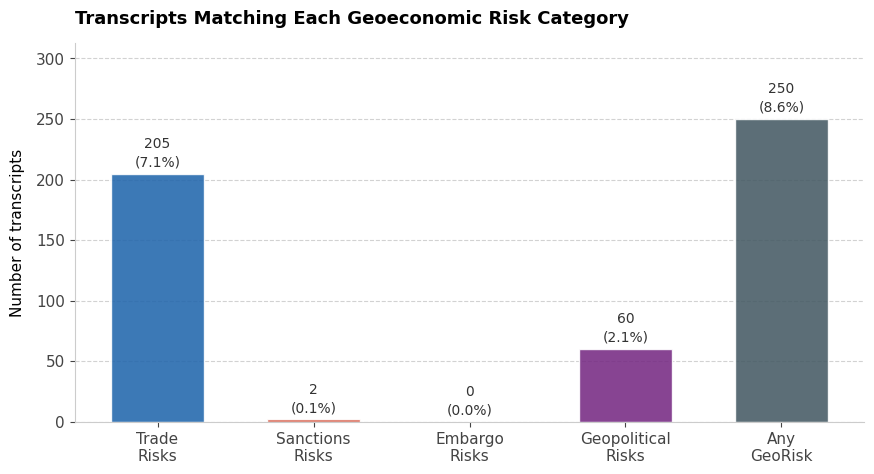

Saved figures/10_georisk_match_counts.png


In [7]:
# --- Fig 1: Match counts per category ---

# Style settings
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

RISK_COLORS = ['#2166AC', '#D6604D', '#4DAC26', '#762A83', '#455A64']

categories = {
    'Trade\nRisks':        'trade_risk',
    'Sanctions\nRisks':    'sanctions_risk',
    'Embargo\nRisks':      'embargo_risk',
    'Geopolitical\nRisks': 'geopolitical_risk',
    'Any\nGeoRisk':        'any_georisk',
}

labels = list(categories.keys())
counts = [docs[v].sum() for v in categories.values()]
pcts   = [100 * c / total for c in counts]
x      = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, counts, color=RISK_COLORS, alpha=0.88,
              edgecolor='white', linewidth=1.0, width=0.60)

for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.015,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, color='#333333', linespacing=1.4)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Number of transcripts', fontsize=11, labelpad=8)
ax.set_title('Transcripts Matching Each Geoeconomic Risk Category',
             fontsize=13, fontweight='bold', pad=14, loc='left')
ax.set_ylim(0, max(counts) * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
ax.tick_params(axis='both', colors='#444444')
plt.tight_layout(pad=1.5)
plt.savefig('figures/10_georisk_match_counts.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/10_georisk_match_counts.png')

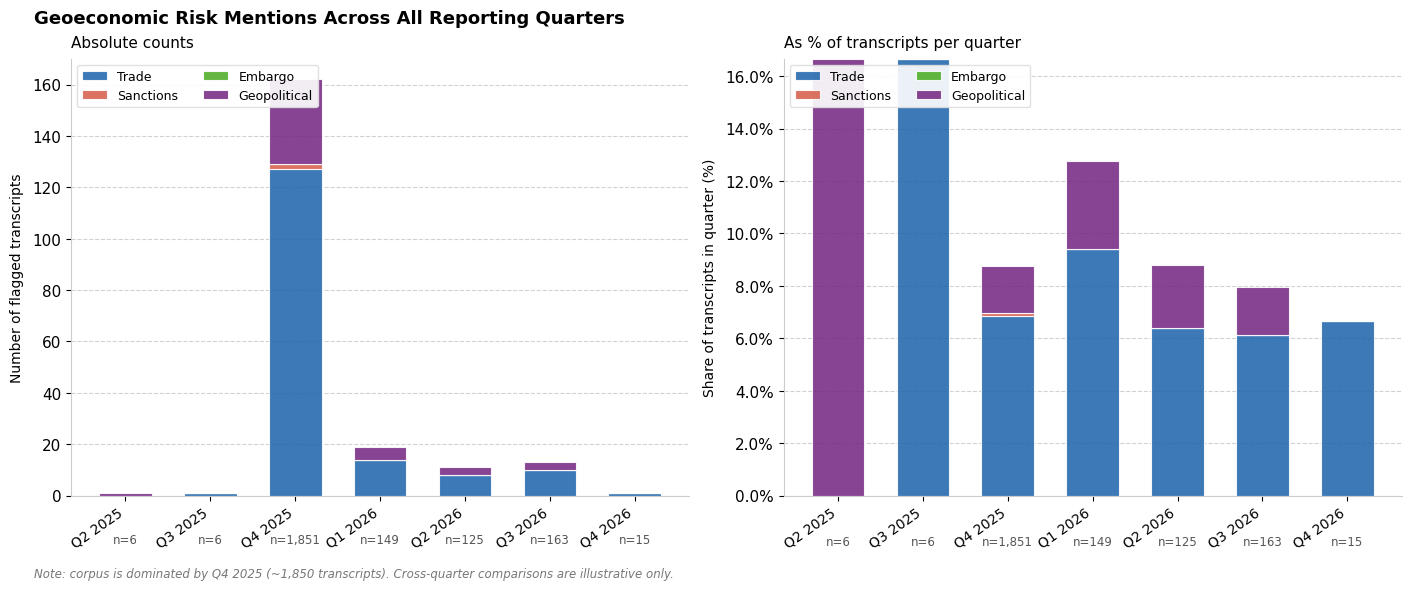

Saved figures/11_georisk_by_period.png


In [8]:
# --- Fig 2: Stacked bar by reporting period (ALL available quarters) ---
# Shows how the mix of geoeconomic risk categories evolves across quarters.
# n= labels indicate the number of transcripts in each quarter so that the
# very different sample sizes are immediately visible.

PERIOD_ORDER = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025',
                'Q1 2026', 'Q2 2026', 'Q3 2026', 'Q4 2026']
available   = docs['reporting_period'].dropna().unique()
PERIODS     = [p for p in PERIOD_ORDER if p in available]

risk_cols   = ['trade_risk', 'sanctions_risk', 'embargo_risk', 'geopolitical_risk']
risk_labels = ['Trade', 'Sanctions', 'Embargo', 'Geopolitical']

period_data = (
    docs[docs['reporting_period'].isin(PERIODS)]
    .groupby('reporting_period')[risk_cols]
    .sum()
    .reindex(PERIODS)
)
period_totals = (
    docs[docs['reporting_period'].isin(PERIODS)]
    .groupby('reporting_period').size()
    .reindex(PERIODS)
)
period_pct = period_data.div(period_totals, axis=0) * 100

n_p   = len(PERIODS)
x     = np.arange(n_p)
W     = 0.62
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle('Geoeconomic Risk Mentions Across All Reporting Quarters',
             fontsize=13, fontweight='bold', x=0.02, ha='left')

for ax, data, ylabel, use_pct in zip(
    axes,
    [period_data, period_pct],
    ['Number of flagged transcripts', 'Share of transcripts in quarter (%)'],
    [False, True]
):
    bottom = np.zeros(n_p)
    for col, label, color in zip(risk_cols, risk_labels, RISK_COLORS[:4]):
        vals = data[col].values.astype(float)
        ax.bar(x, vals, bottom=bottom, label=label, color=color,
               alpha=0.88, width=W, edgecolor='white', linewidth=0.8)
        bottom += vals

    # n= annotation below each bar group
    for xi, (period, n) in enumerate(zip(PERIODS, period_totals.values)):
        ax.text(xi, -bottom.max() * 0.09, f'n={n:,}',
                ha='center', va='top', fontsize=8.5, color='#555555')

    ax.set_xticks(x)
    ax.set_xticklabels(PERIODS, rotation=35, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=6)
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#dddddd',
              loc='upper left', ncol=2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
    ax.set_axisbelow(True)
    if use_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

axes[0].set_title('Absolute counts', fontsize=11, pad=8, loc='left')
axes[1].set_title('As % of transcripts per quarter', fontsize=11, pad=8, loc='left')

fig.text(0.02, -0.04,
         'Note: corpus is dominated by Q4 2025 (~1,850 transcripts). '
         'Cross-quarter comparisons are illustrative only.',
         fontsize=8.5, color='#777777', style='italic')

plt.savefig('figures/11_georisk_by_period.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/11_georisk_by_period.png')

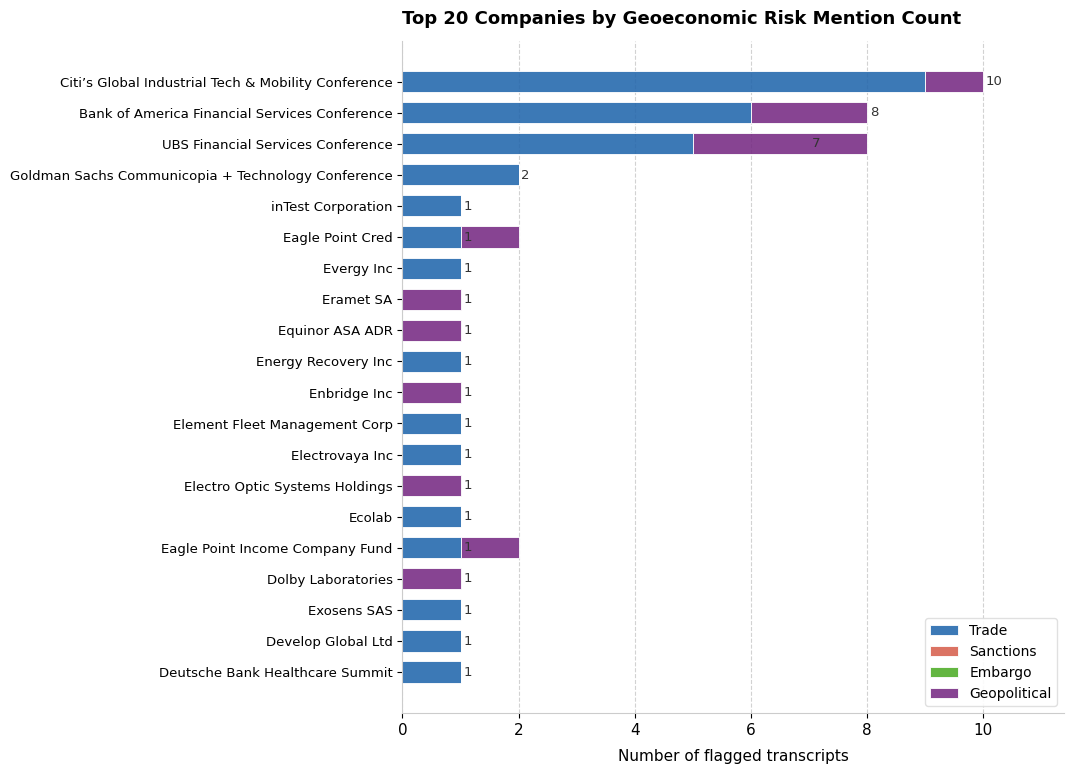


Top 20 companies:
                                                     n_transcripts  trade  sanctions  embargo  geopolitical
company_name                                                                                               
Deutsche Bank Healthcare Summit                                  1      1          0        0             0
Develop Global Ltd                                               1      1          0        0             0
Exosens SAS                                                      1      1          0        0             0
Dolby Laboratories                                               1      0          0        0             1
Eagle Point Income Company Fund                                  1      1          0        0             1
Ecolab                                                           1      1          0        0             0
Electro Optic Systems Holdings                                   1      0          0        0             1
Electrova

In [9]:
# --- Fig 3: Top 20 companies by geoeconomic risk mention count ---

top_companies = (
    matched[matched['company_name'].notna()]
    .groupby('company_name')
    .agg(
        n_transcripts = ('any_georisk', 'sum'),
        trade         = ('trade_risk', 'sum'),
        sanctions     = ('sanctions_risk', 'sum'),
        embargo       = ('embargo_risk', 'sum'),
        geopolitical  = ('geopolitical_risk', 'sum'),
    )
    .sort_values('n_transcripts', ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(11, 8))
y    = np.arange(len(top_companies))
left = np.zeros(len(top_companies))

for col, label, color in zip(
    ['trade', 'sanctions', 'embargo', 'geopolitical'],
    risk_labels, RISK_COLORS[:4]
):
    vals = top_companies[col].values.astype(float)
    ax.barh(y, vals, left=left, label=label, color=color,
            alpha=0.88, edgecolor='white', linewidth=0.7, height=0.68)
    left += vals

# Total label at end of each bar
for yi, total_val in enumerate(top_companies['n_transcripts'].values):
    ax.text(total_val + 0.05, yi, f'{total_val}',
            va='center', ha='left', fontsize=9.5, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels(top_companies.index, fontsize=9.5)
ax.set_xlabel('Number of flagged transcripts', fontsize=11, labelpad=8)
ax.set_title('Top 20 Companies by Geoeconomic Risk Mention Count',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#dddddd', loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
ax.set_xlim(0, top_companies['n_transcripts'].max() * 1.14)
fig.set_facecolor('white')
plt.tight_layout(pad=1.5)
plt.savefig('figures/12_georisk_top_companies.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()

print('\nTop 20 companies:')
print(top_companies.to_string())

## Summary

Matching now uses **sentence-level co-occurrence**: both a topic keyword and a risk/uncertainty keyword must appear in the **same sentence**, reducing false positives from transcripts that happen to mention both terms in unrelated passages.

| File | Description |
|---|---|
| `data/geoeconomic_matches.csv` | Full corpus with `True/False` flags for each of the 4 risk categories |
| `data/geoeconomic_matches_flagged.csv` | Subset: only transcripts matching at least one category |
| `figures/10_georisk_match_counts.png` | Count and share per category |
| `figures/11_georisk_by_period.png` | Distribution across all reporting quarters (n= labels show sample size) |
| `figures/12_georisk_top_companies.png` | Top 20 companies by mention count |

> **Note on sample balance:** The corpus is dominated by Q4 2025 earnings calls (~1,850 transcripts out of ~2,900 total). The remaining quarters each contain only tens to low hundreds of transcripts. Cross-quarter comparisons in figure 11 are therefore **illustrative only**; a sample with comparable transcript counts per quarter would be required for reliable temporal inference.